# Gradiente de concentración en una partícula catalítica

Cuando una reacción ocurre en una partícula porosa, la concentración del reactivo puede ser menor en el interior que en la superficie. Esta idea se formaliza con el módulo de Thiele, introducido para relacionar actividad catalítica y tamaño de partícula, y con criterios como Weisz-Prater para detectar limitaciones difusionales {cite:p}`thiele1939catalytic_activity_particle_size,weisz1954experimental_catalysis`.

Para una reacción de primer orden en una partícula esférica, una escala útil es:

$$
\phi = R_p\sqrt{\frac{k}{D_e}}
$$

La figura compara transferencia externa, difusión interna y cinética. Ahora el eje vertical se ajusta automáticamente al rango útil de los perfiles y se marcan centro y superficie para que el progreso radial se lea con más claridad.

```{admonition} Qué puedes modificar
:class: dropdown
Cambia `kf`, `De` o `k` en la lista `scenarios`. Si $D_e$ baja o $k$ sube, $\phi$ aumenta y el perfil interior cae con más fuerza.
```


Resumen de escenarios
Transferencia rapida: phi=0.40, eta=0.99, C_surface/C_bulk=1.00
Difusion interna baja: phi=0.90, eta=0.95, C_surface/C_bulk=1.00
Pelicula externa lenta: phi=0.40, eta=0.99, C_surface/C_bulk=0.98
Cinetica rapida: phi=0.76, eta=0.96, C_surface/C_bulk=0.99


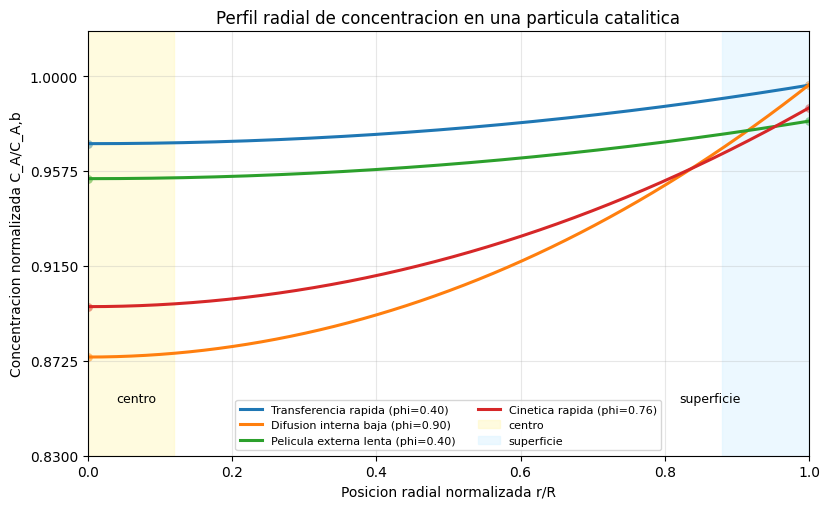

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Editable parameters
R_particle = 1.5e-3   # m
C_bulk = 1.0          # mol/L, used as reference
scenarios = [('Transferencia rapida', 0.03, 3.5e-06, 0.25), ('Difusion interna baja', 0.03, 7e-07, 0.25), ('Pelicula externa lenta', 0.006, 3.5e-06, 0.25), ('Cinetica rapida', 0.03, 3.5e-06, 0.9)]


def effectiveness_factor(phi):
    if phi < 1e-6:
        return 1.0
    return 3 / phi**2 * (phi / np.tanh(phi) - 1)


def profile(r_over_R, kf, De, k):
    phi = R_particle * np.sqrt(k / De)
    eta = effectiveness_factor(phi)
    C_surface = C_bulk / (1 + eta * k * R_particle / (3 * kf))
    r_safe = np.maximum(r_over_R, 1e-6)
    internal = np.sinh(phi * r_safe) / (r_safe * np.sinh(phi)) if phi > 1e-6 else np.ones_like(r_safe)
    internal[0] = phi / np.sinh(phi) if phi > 1e-6 else 1.0
    return C_surface * internal / C_bulk, phi, eta, C_surface / C_bulk


r = np.linspace(0, 1, 250)
profiles = []
print("Resumen de escenarios")
for name, kf, De, k in scenarios:
    C, phi, eta, Cs = profile(r, kf, De, k)
    profiles.append((name, C, phi, eta, Cs))
    print(f"{name}: phi={phi:.2f}, eta={eta:.2f}, C_surface/C_bulk={Cs:.2f}")

y_min = max(0.0, min(C.min() for _, C, _, _, _ in profiles) - 0.04)
y_max = 1.02

fig, ax = plt.subplots(figsize=(8.4, 5.2))
for name, C, phi, eta, Cs in profiles:
    ax.plot(r, C, linewidth=2.2, label=f"{name} (phi={phi:.2f})")
    ax.scatter([0, 1], [C[0], C[-1]], s=28)

ax.axvspan(0, 0.12, color="#fff8c5", alpha=0.55, label="centro")
ax.axvspan(0.88, 1, color="#ddf4ff", alpha=0.55, label="superficie")
ax.set_xlim(0, 1)
ax.set_ylim(y_min, y_max)
ax.set_xticks(np.linspace(0, 1, 6))
ax.set_yticks(np.linspace(round(y_min, 2), 1.0, 5))
ax.set_xlabel("Posicion radial normalizada r/R")
ax.set_ylabel("Concentracion normalizada C_A/C_A,b")
ax.set_title("Perfil radial de concentracion en una particula catalitica")
ax.grid(alpha=0.3)
ax.annotate("centro", xy=(0.04, y_min + 0.02), fontsize=9)
ax.annotate("superficie", xy=(0.82, y_min + 0.02), fontsize=9)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## Interpretación

Si la difusión interna es lenta o la cinética es rápida, aparece un gradiente acusado dentro de la partícula. Si la transferencia externa es lenta, incluso la concentración en la superficie cae por debajo de la concentración en el fluido.

```{admonition} Lectura guiada
:class: dropdown
Compara los puntos marcados en $r/R=0$ y $r/R=1$. La separación entre ambos resume la pérdida interna; la caída de la superficie respecto a $1$ resume la resistencia externa.
```
